# End-to-End Predictive Analytics: Rossmann Store Sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


## 1. Data Collection

In [ ]:
df = pd.read_csv(r'train.csv', dtype={'StateHoliday': str})
print(df.shape)
df.info()

(1017209, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB


In [3]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


The dataset has **1,017,209 rows** and 9 columns — daily sales records for 1,115 Rossmann stores.

## 2. Data Cleaning

In [4]:
print('Duplicate rows:', df.duplicated().sum())
print()
print(df.isnull().sum())


Duplicate rows: 0

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


No duplicate rows and no missing values.

**Filtering closed-store days.** `Open == 0` means the store was closed, so `Sales` is
trivially 0 — not a real forecasting scenario, and leaving these rows in would let the model
"cheat" by learning `Open -> 0` instead of real demand patterns.

In [5]:
print(df['Open'].value_counts())
df = df[df['Open'] == 1].copy()
print('Shape after filtering closed days:', df.shape)


Open
1    844392
0    172817
Name: count, dtype: int64


Shape after filtering closed days: (844392, 9)


**`StateHoliday` is left as a raw categorical string here** (not manually mapped or
dummy-encoded) — its encoding will be handled inside the model pipeline below via
`OneHotEncoder`, so that encoding is properly fit only on training data and bundled with
the model as a single deployable object.

In [6]:
df['StateHoliday'].value_counts()

StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

## 3. Feature Engineering

**Calendar features from `Date`.** We extract year, month, day, ISO week of year, and a
weekend flag, then drop the raw date — these capture seasonality and weekly demand cycles
likely to matter for retail sales.

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,IsWeekend
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31,0
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31,0
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,31,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,31,0
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,31,0


**Data leakage check — `Customers`.** Before dropping anything, let's check what's actually correlated with `Sales`.

In [8]:
corr_check = df.drop(columns=['Date']).corr(numeric_only=True)
corr_check['Sales'].sort_values(ascending=False)


Sales            1.000000
Customers        0.823597
Promo            0.368145
WeekOfYear       0.074472
Month            0.073600
SchoolHoliday    0.038617
Year             0.036169
Store            0.007710
Day             -0.051849
IsWeekend       -0.151780
DayOfWeek       -0.178736
Open                  NaN
Name: Sales, dtype: float64

`Customers` correlates at **~0.82** with `Sales` — far higher than anything else. But
customer count and sales are recorded for the *same day*, so in a real forecasting setting
(predicting sales ahead of time) `Customers` would not be known in advance. Including it
would make the model look far stronger than it really is for its intended use. We drop it,
along with the now-constant `Open` column and the raw `Date` (already decomposed above).

In [9]:
df_model = df.drop(columns=['Date', 'Open', 'Customers'])
X = df_model.drop(columns=['Sales'])
y = df_model['Sales']
print(X.columns.tolist())
df_model.shape


['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend']


(844392, 11)

## 4. Exploratory Data Analysis

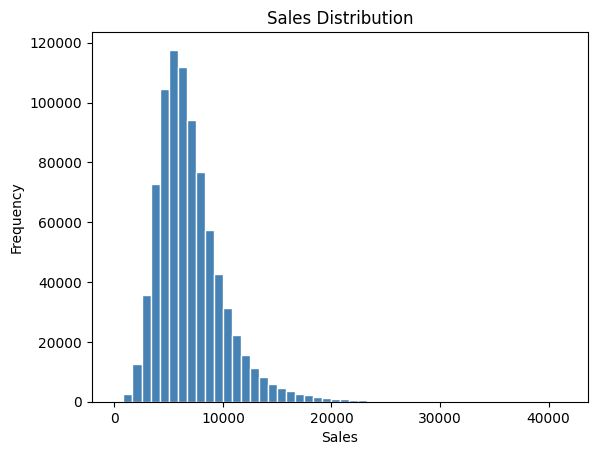

Skew: 1.5939220392699807


In [10]:
df_model['Sales'].plot(kind='hist', bins=50, color='steelblue', edgecolor='white')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.show()
print('Skew:', df_model['Sales'].skew())


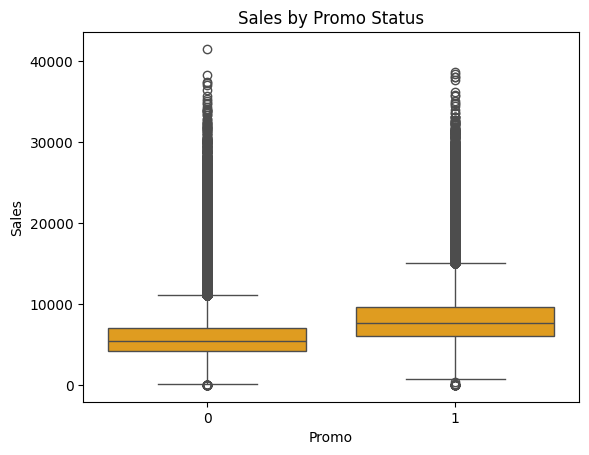

In [11]:
sns.boxplot(x=df_model['Promo'], y=df_model['Sales'], color='orange')
plt.title('Sales by Promo Status')
plt.show()


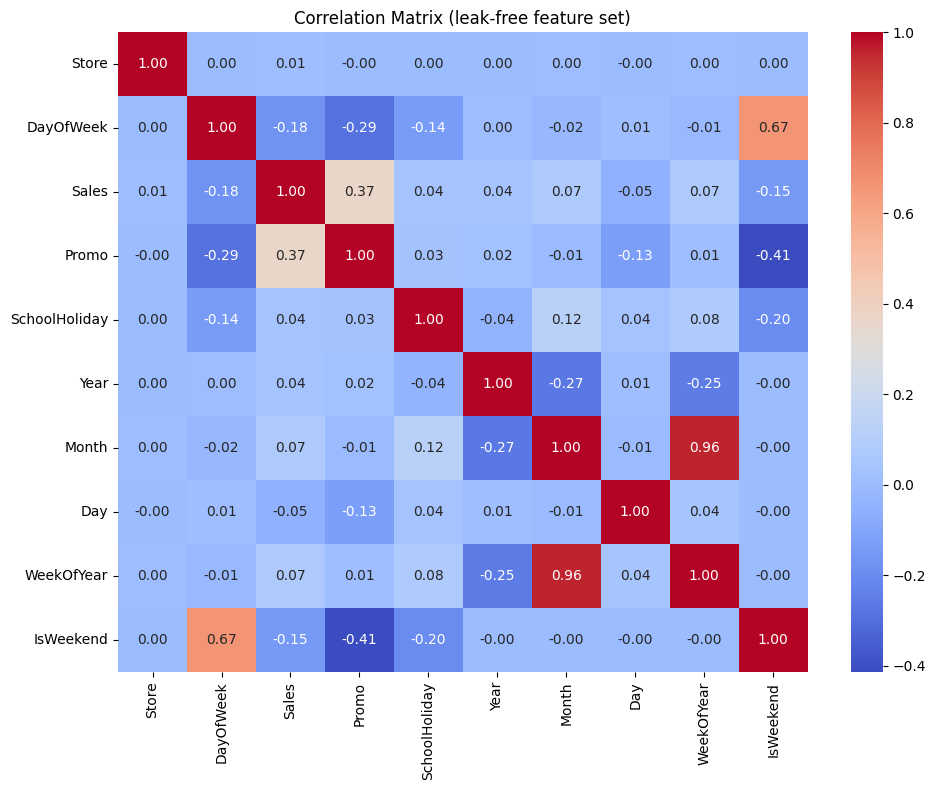

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_model.drop(columns=['StateHoliday']).corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix (leak-free feature set)')
plt.tight_layout()
plt.show()


Sales is right-skewed, as expected for retail transaction data. `Promo` clearly shifts
sales upward. With `Customers` removed, no single feature dominates the correlation matrix —
a more honest picture of what's predictable from information available before the sales day.

## 5. Model Training — building an `sklearn.Pipeline`

Instead of manually one-hot encoding and feeding a raw DataFrame into the model, we wrap
preprocessing and the model together in a single `Pipeline`. This is the production-appropriate
approach: the pipeline can be fit, tuned, evaluated, and saved/deployed as **one object**, and
the encoder is guaranteed to only ever be fit on training data (no leakage from fitting an
encoder on the full dataset before splitting).

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import joblib

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

categorical_features = ['StateHoliday']
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42,
                                tree_method='hist', n_estimators=150, n_jobs=1))
])
pipeline


Train: (540410, 10) Val: (135103, 10) Test: (168879, 10)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

A validation split is held out purely for **early stopping** later — training halts
once validation error stops improving, one guard against overfitting.

## 6. Hyperparameter Tuning

`RandomizedSearchCV` is run directly **on the pipeline**, using `regressor__<param>` keys
so the search reaches through the pipeline into the model step. The search includes explicit
**regularization** parameters (`reg_lambda`, `min_child_weight`, `max_depth`) — these are the
main lever against overfitting, the focus of Question 1 below.

In [14]:
param_dist = {
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [4, 6, 8],
    'regressor__subsample': [0.7, 0.9],
    'regressor__colsample_bytree': [0.7, 0.9],
    'regressor__min_child_weight': [1, 5],
    'regressor__reg_lambda': [1, 5],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=6,
    cv=2,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1,
    random_state=42
)
search.fit(X_train, y_train)
print('Best parameters:', search.best_params_)


Fitting 2 folds for each of 6 candidates, totalling 12 fits


Best parameters: {'regressor__subsample': 0.7, 'regressor__reg_lambda': 1, 'regressor__min_child_weight': 1, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.2, 'regressor__colsample_bytree': 0.7}


**Note on scale:** `n_iter=6`, `cv=2` keeps this notebook runnable quickly on ~840k rows
on a single core. In production this search would be widened (more iterations, `cv=5`) and
parallelized with `n_jobs=-1` across available cores, or run on a sample as discussed in
Question 2 below.

**Final model.** We now refit the pipeline once more with the best hyperparameters, this time
using early stopping. Because `eval_set` for XGBoost early stopping needs already-transformed
validation data, we fit the preprocessor step once, transform train/val through it, fit the
regressor with early stopping, then re-assemble everything into a single final `Pipeline` —
still one deployable object, just fit in two steps internally.

In [15]:
best_params = {k.replace('regressor__', ''): v for k, v in search.best_params_.items()}

final_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

X_train_enc = final_preprocessor.fit_transform(X_train)
X_val_enc = final_preprocessor.transform(X_val)

final_regressor = XGBRegressor(
    objective='reg:squarederror', random_state=42, tree_method='hist',
    n_estimators=800, early_stopping_rounds=30, n_jobs=1, **best_params
)
final_regressor.fit(X_train_enc, y_train, eval_set=[(X_val_enc, y_val)], verbose=False)
print('Best iteration (early stopping):', final_regressor.best_iteration)

final_pipeline = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    ('regressor', final_regressor)
])


Best iteration (early stopping): 286


## 7. Model Evaluation

In [16]:
pred = final_pipeline.predict(X_test)

rmse = root_mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'R2:   {r2:.4f}')


RMSE: 2416.47
MAE:  1762.96
R2:   0.3945


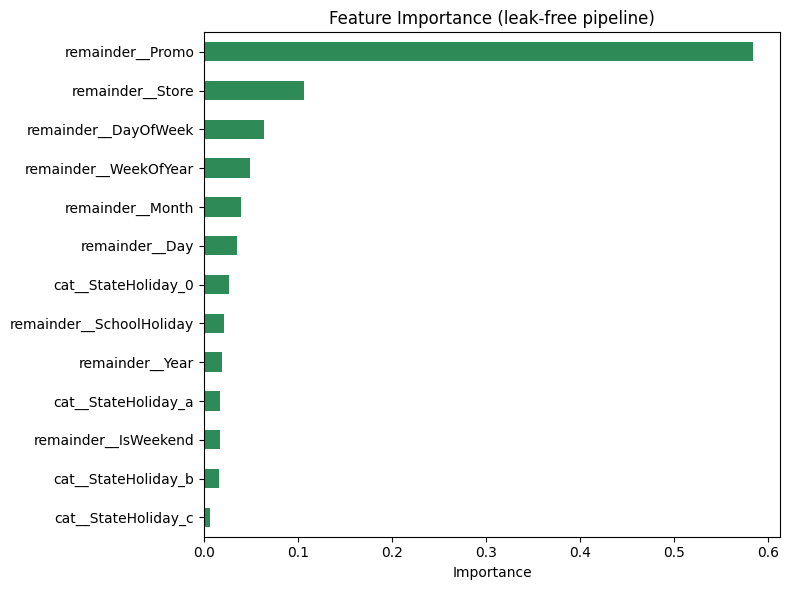

In [17]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(final_pipeline.named_steps['regressor'].feature_importances_,
                         index=feature_names).sort_values()
importances.plot(kind='barh', figsize=(8, 6), color='seagreen')
plt.title('Feature Importance (leak-free pipeline)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Making the leakage concrete.** As a sanity check, here's what happens if we put
`Customers` back in as a feature — same pipeline structure, same hyperparameters, same split —
just to quantify how much of a naive model's performance comes from a feature that isn't
available at prediction time.

In [18]:
X_leak = df.drop(columns=['Date', 'Open', 'Sales'])
y_leak = df['Sales']

Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_leak, y_leak, test_size=0.2, random_state=42)
Xl_train, Xl_val, yl_train, yl_val = train_test_split(Xl_train, yl_train, test_size=0.2, random_state=42)

leak_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')
Xl_train_enc = leak_preprocessor.fit_transform(Xl_train)
Xl_val_enc = leak_preprocessor.transform(Xl_val)

leak_regressor = XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist',
                               n_estimators=300, early_stopping_rounds=20, n_jobs=1, **best_params)
leak_regressor.fit(Xl_train_enc, yl_train, eval_set=[(Xl_val_enc, yl_val)], verbose=False)

leak_pipeline = Pipeline(steps=[('preprocessor', leak_preprocessor), ('regressor', leak_regressor)])
pred_leak = leak_pipeline.predict(Xl_test)

print('WITH Customers    -> RMSE: {:.1f}, R2: {:.4f}'.format(
    root_mean_squared_error(yl_test, pred_leak), r2_score(yl_test, pred_leak)))
print('WITHOUT Customers -> RMSE: {:.1f}, R2: {:.4f}'.format(rmse, r2))


WITH Customers    -> RMSE: 1049.7, R2: 0.8857
WITHOUT Customers -> RMSE: 2416.5, R2: 0.3945


The gap between the two is the leakage effect: R2 nearly doubles when `Customers` is
included, purely because it's measured concurrently with `Sales`, not because the model learned
anything more useful for actual forecasting. **The leak-free pipeline above is the one that
reflects real-world deployment performance.**

In [19]:
joblib.dump(final_pipeline, 'sales_forecast_pipeline.pkl')
print('Pipeline (preprocessing + model, as one object) saved.')


Pipeline (preprocessing + model, as one object) saved.


## 8. Business Insights

- **Promotions are the strongest lever known in advance**: `Promo` is the top feature in
  the leak-free model — running a promotion measurably shifts sales upward (see the boxplot
  above). Directly actionable for promo scheduling.
- **Store identity matters a lot**: individual `Store` is highly important, meaning stores
  differ substantially in baseline sales (location, size, local demographics) — store-level
  clustering or per-store correction could improve accuracy further.
- **Calendar effects are real but secondary**: `DayOfWeek`, `WeekOfYear`, `Day`, and `Month`
  collectively carry meaningful weight — useful for staffing and inventory planning around
  known high/low-demand periods.
- **`Customers` should not be used as an input feature for forecasting**, even though it's the
  strongest raw correlate of `Sales` — it isn't known ahead of time. If the goal is
  understanding *what drives* sales rather than *forecasting* it, `Customers` can instead be
  studied as an outcome variable in its own right.
- **Honest vs. inflated performance**: the leak-free forecasting pipeline explains roughly 39%
  of test variance (R2 ≈ 0.39–0.40, RMSE ≈ 2,400) — a materially harder, but realistic, number
  that should be reported to stakeholders, since it reflects what the model can actually do at
  prediction time, versus the ~0.89–0.94 obtained with leaked information.


## Question 1: Why 99% training accuracy but only 74% testing accuracy?

**Root cause: overfitting.** The model has memorized patterns specific to the training
set — including noise — rather than learning generalizable relationships. Common causes:
- the model is too complex relative to the amount/diversity of training data (very deep trees,
  too many boosting rounds without early stopping),
- the training data isn't representative of the full population seen at test time, or
- there are too many features relative to signal, letting the model fit idiosyncrasies
  (including leaky features, as demonstrated above).

**Techniques to improve generalization:**
1. **Regularization** — increase `reg_alpha`/`reg_lambda`, raise `min_child_weight`, reduce
   `max_depth`, and use `subsample`/`colsample_bytree` < 1 (all searched above).
2. **Early stopping** on a held-out validation set (used here) — stop boosting once validation
   error plateaus, rather than training a fixed large number of rounds.
3. **Cross-validation during hyperparameter search** (`RandomizedSearchCV`, `cv=2`–5 above) so
   chosen parameters generalize across folds, not just one split.
4. **Feature selection / leakage audits** — remove features (like `Customers` here) that leak
   future information or add noise without real signal.
5. **More / more diverse training data** — reduces the chance the model fits sampling artifacts.
6. **Simpler models or ensembling** — a shallower tree ensemble, or averaging several
   regularized models, often generalizes better than one very complex model.

Note: **stratified splitting and SMOTE, mentioned in the earlier draft, are classification
techniques for class imbalance and don't apply here**, since `Sales` is a continuous
regression target, not a set of classes to balance.


## Question 2: Redesigning the workflow for 50 million records

At 50M rows, the current approach (pandas in memory, single-machine `RandomizedSearchCV`)
would become slow or infeasible. Redesign points:

1. **Storage format** — move from CSV to **Parquet** (columnar, compressed, faster I/O,
   supports column/predicate pushdown so only needed columns/rows load).
2. **Processing engine** — replace pandas with a distributed/out-of-core engine such as
   **Dask, Polars, or Spark**, so data is processed across cores/machines without loading
   everything into one process's memory. The `Pipeline` structure built above still applies —
   Spark's MLlib and Dask-ML both support the same preprocessing-plus-model pipeline pattern.
3. **Prototype on a sample first** — develop and validate the pipeline (cleaning, feature
   engineering, hyperparameter search) on a representative sample (a few million rows), then
   port the finalized configuration to the full dataset, rather than paying full compute cost
   for every experiment.
4. **Distributed / GPU training** — use XGBoost's native distributed support (`Dask-XGBoost` or
   Spark's XGBoost integration) or GPU acceleration (`tree_method='hist', device='cuda'`) to
   keep training time manageable; `tree_method='hist'` (already used here) scales far better
   than exact tree methods.
5. **Lighter hyperparameter search** — run the search on the sample only, with smaller `cv` and
   fewer iterations, then do one final fit with early stopping on the full 50M rows using the
   chosen parameters, instead of repeating full-data training many times.
6. **Chunked / incremental evaluation** — compute metrics over the test set in batches rather
   than loading the full test set into memory at once, if memory-constrained.
7. **Cost control** — use spot/preemptible instances for exploratory sampling, and reserve
   full/on-demand compute only for the final full-data training run.

**On evaluation metrics:** RMSE and R2 remain appropriate for this regression task at any
scale — RMSE gives error in the original Sales units (business-interpretable), R2 gives
proportion of variance explained. As shown above, high R2 does *not* by itself confirm good
generalization if input features contain leakage — always check what information the features
actually make available at prediction time.
